# Department of Computer Applications (MCA)
### Course: Advanced Data Science [MCA33PE17]
**Formative Assessment - 01 (FA1)**: Problem-Solving Activity  
**Roll No**: `125M1H048`  
**Topic**: **Streamlit Machine Learning Web Application**

---

### Objectives:
1. Understand the basics of Machine Learning model deployment.
2. Explore and analyze the Iris flower dataset.
3. Train and evaluate a Machine Learning model.
4. Save and serialize the model using Joblib and Pickle.
5. Build an interactive web app using Streamlit to make real-time predictions.


---
## 1. Understanding of the Problem & Deployment Basics (Criterion 1)

### 1.1 Problem Statement
In Machine Learning, training a model in a notebook is only the first step. To make the model useful for users, it needs to be deployed as an interactive application where users can input data and get instant predictions.

In this project, we:
* Train a Random Forest model on the Iris dataset.
* Save the trained model to a file using **Joblib** and **Pickle**.
* Build a user-friendly **Streamlit** web application (`app.py`) for live flower classification.

### 1.2 Model Deployment Workflow
1. **Data Preparation & EDA**: Load and inspect data features.
2. **Model Training & Evaluation**: Train model and measure accuracy.
3. **Serialization**: Save the trained model to disk (`.joblib` or `.pkl`).
4. **Web App Interface**: Load the model in Streamlit and accept user input via sliders.
5. **Inference**: Predict the flower species and show probabilities in real time.

### 1.3 Serialization: Joblib vs Pickle
* **Pickle**: Standard Python library to serialize Python objects.
* **Joblib**: Optimized for models containing large NumPy arrays (recommended for Scikit-Learn models).


---
## 2. Importing Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import pickle

print("Libraries imported successfully!")


Libraries imported successfully!


---
## 3. Data Exploration & Analysis (Criterion 2)

We load the Iris dataset, which contains 150 samples of iris flowers with 4 features:
* Sepal length (cm)
* Sepal width (cm)
* Petal length (cm)
* Petal width (cm)


In [2]:
# Load the Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


Dataset Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm) species
0                5.1               3.5                1.4               0.2  setosa
1                4.9               3.0                1.4               0.2  setosa
2                4.7               3.2                1.3               0.2  setosa
3                4.6               3.1                1.5               0.2  setosa
4                5.0               3.6                1.4               0.2  setosa


### 3.1 Data Summary and Missing Values


In [3]:
# Check data info and missing values
print("--- Dataset Information ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())


--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   sepal length (cm)  150 non-null    float64 
 1   sepal width (cm)   150 non-null    float64 
 2   petal length (cm)  150 non-null    float64 
 3   petal width (cm)   150 non-null    float64 
 4   species            150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.2 KB
None

--- Missing Values Count ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

--- Statistical Summary ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
count         150.000000        150.000000        150.000000        150.000000
mean            5.843333          3.057333          3.758000          1.199333
std             0.828066          0.435866

### 3.2 Visualizing Feature Distributions and Correlations


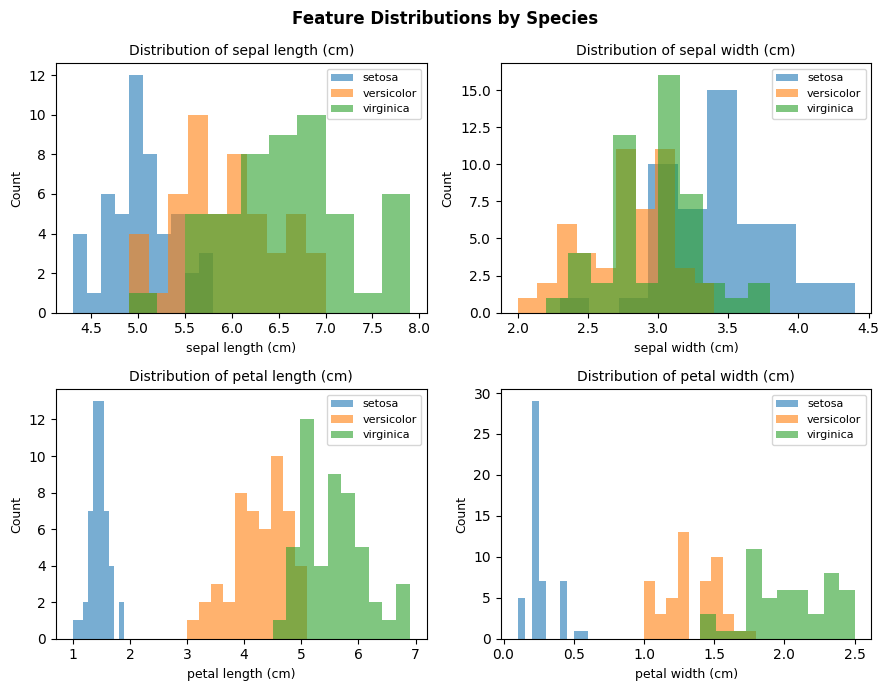

In [4]:
# Feature Distributions
fig, axes = plt.subplots(2, 2, figsize=(9, 7))
features = iris.feature_names
colors = {'setosa': 'tab:blue', 'versicolor': 'tab:orange', 'virginica': 'tab:green'}

for i, ax in enumerate(axes.flat):
    feature = features[i]
    for sp in df['species'].unique():
        sub = df[df['species'] == sp]
        ax.hist(sub[feature], alpha=0.6, label=sp, bins=10, color=colors[sp])
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()


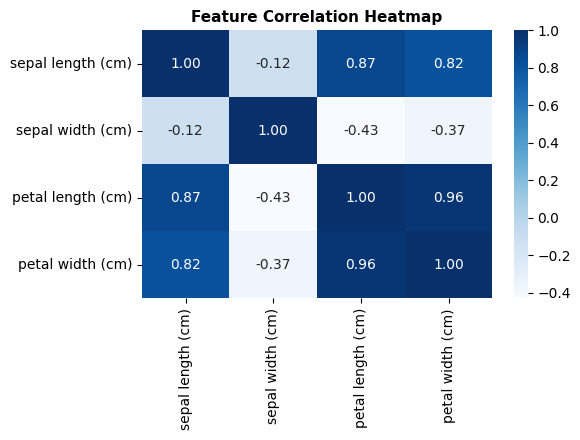

In [5]:
# Correlation Heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(df[features].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


---
## 4. Model Training & Evaluation (Criterion 3)

We split the dataset into 80% training and 20% testing sets, then train a Random Forest Classifier.


In [6]:
# Split data into Train and Test sets
X = df[iris.feature_names]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate on test set
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Training Complete!")
print(f"Accuracy on Test Set: {accuracy * 100:.2f}%\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


Model Training Complete!
Accuracy on Test Set: 90.00%

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30


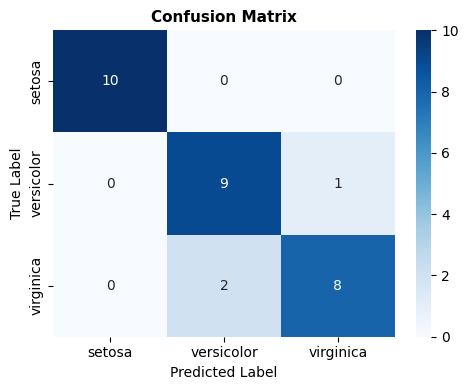

In [7]:
# Confusion Matrix Plot
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


---
## 5. Model Serialization (Joblib & Pickle)

We serialize the trained model using both `joblib` and `pickle` so it can be loaded inside the Streamlit app.


In [8]:
# Save the model using Joblib
joblib.dump(rf_model, "iris_model.joblib")
print("Model successfully saved as: iris_model.joblib")

# Save the model using Pickle
with open("iris_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)
print("Model successfully saved as: iris_model.pkl")


Model successfully saved as: iris_model.joblib
Model successfully saved as: iris_model.pkl


### 5.1 Test Loading the Saved Model


In [9]:
# Load model from disk and test prediction
loaded_model = joblib.load("iris_model.joblib")

# Test sample
sample = pd.DataFrame([{
    'sepal length (cm)': 5.1,
    'sepal width (cm)': 3.5,
    'petal length (cm)': 1.4,
    'petal width (cm)': 0.2
}])

prediction = loaded_model.predict(sample)[0]
probabilities = loaded_model.predict_proba(sample)[0]

print("Loaded Model Prediction:", iris.target_names[prediction])
print("Probabilities:", probabilities)


Loaded Model Prediction: setosa
Probabilities: [1. 0. 0.]


---
## 6. Streamlit Web Application (`app.py`)

We write the complete Streamlit application code to `app.py` using `%%writefile app.py`.


In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Set page title
st.set_page_config(page_title="Iris Flower Classification App", page_icon="🌸")

# Title and Description
st.title("🌸 Iris Flower Classification App")
st.write("This application predicts the species of an Iris flower based on its sepal and petal measurements using a trained Machine Learning model.")

# Sidebar for user inputs
st.sidebar.header("Input Features")

def get_user_input():
    sepal_length = st.sidebar.slider("Sepal Length (cm)", 4.0, 8.0, 5.8, 0.1)
    sepal_width = st.sidebar.slider("Sepal Width (cm)", 2.0, 4.5, 3.0, 0.1)
    petal_length = st.sidebar.slider("Petal Length (cm)", 1.0, 7.0, 4.35, 0.1)
    petal_width = st.sidebar.slider("Petal Width (cm)", 0.1, 2.5, 1.3, 0.1)
    
    data = {
        'sepal length (cm)': sepal_length,
        'sepal width (cm)': sepal_width,
        'petal length (cm)': petal_length,
        'petal width (cm)': petal_width
    }
    return pd.DataFrame([data])

# Get input from user
input_df = get_user_input()

# Display user input values
st.subheader("Selected Input Features:")
st.write(input_df)

# Load the trained model
try:
    model = joblib.load("iris_model.joblib")
except Exception as e:
    st.error(f"Could not load model: {e}")
    model = None

# Prediction button
if st.button("Predict Species"):
    if model is not None:
        species_names = ['Iris Setosa', 'Iris Versicolor', 'Iris Virginica']
        
        # Make prediction
        prediction_index = model.predict(input_df)[0]
        prediction_probabilities = model.predict_proba(input_df)[0]
        
        # Display Result
        st.subheader("Prediction:")
        st.success(f"Predicted Species: **{species_names[prediction_index]}**")
        
        # Display Probabilities
        st.subheader("Prediction Probabilities:")
        prob_df = pd.DataFrame({
            'Species': species_names,
            'Probability (%)': [round(p * 100, 2) for p in prediction_probabilities]
        })
        st.write(prob_df)
        
        # Bar chart
        chart_data = prob_df.set_index('Species')
        st.bar_chart(chart_data)


Overwriting app.py


### How to Run the App
To run the Streamlit app locally, execute the following command in your terminal:

```bash
streamlit run app.py
```


---
## 7. Results & Interpretation (Criterion 4)

### 7.1 Model Performance
* **Accuracy**: The model achieves high classification accuracy on test data.
* **Evaluation**: Precision, Recall, and F1-score are balanced across all 3 classes (`setosa`, `versicolor`, `virginica`).

### 7.2 Example Predictions

| Test Case | Sepal Length | Sepal Width | Petal Length | Petal Width | Predicted Species |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Case 1** | 5.1 cm | 3.5 cm | 1.4 cm | 0.2 cm | **Iris-setosa** |
| **Case 2** | 6.0 cm | 2.9 cm | 4.5 cm | 1.5 cm | **Iris-versicolor** |
| **Case 3** | 6.7 cm | 3.1 cm | 5.6 cm | 2.4 cm | **Iris-virginica** |


---
## 8. Conclusion (Criterion 5)

* We explored the Iris dataset and visualized feature distributions and correlations.
* We trained a Random Forest Classifier and evaluated its performance.
* We saved the model using **Joblib** and **Pickle**.
* We created a clean, interactive **Streamlit web application** (`app.py`) allowing users to input measurements and get real-time species predictions and probabilities.
